**Step 1: Data Generation**

In this section, we programmatically generate a synthetic dataset containing 100 student records with relevant academic fields.

In [2]:
import pandas as pd
import numpy as np

#set random seed for reproducibility
np.random.seed(42)

#define base lists for categorical data
departments = ['Computer Science', 'Data Science', 'Psychology', 'Business Analytics']
semesters = ['Semester 1', 'Semester 2', 'Semester 3', 'Semester 4']

#lists of names for realistic student name generation
first_names = ['John', 'Emily', 'Michael', 'Jessica', 'David', 'Sarah', 'James', 'Ashley', 'Robert', 'Megan']
last_names = ['Smith', 'Johnson', 'Williams', 'Brown', 'Jones', 'Garcia', 'Miller', 'Davis', 'Rodriguez', 'Martinez']

#generate 100 unique student names
student_names = [f"{np.random.choice(first_names)} {np.random.choice(last_names)}" for _ in range(100)]

#generate dependent numerical data (Attendance vs Marks correlation)
attendance = np.random.randint(50, 101, size=100)
base_marks = attendance * 0.8 + np.random.normal(15, 6, size=100)
marks = np.clip(base_marks, 30, 100).astype(int)

#assemble everything into a Pandas DataFrame
data = {
    'Student ID': [f"STU{i:03d}" for i in range(1, 101)],
    'Student Name': student_names,
    'Department': np.random.choice(departments, size=100),
    'Attendance Percentage': attendance,
    'Marks Obtained': marks,
    'Semester': np.random.choice(semesters, size=100)}

df = pd.DataFrame(data)
df.head()

,Student ID,Student Name,Department,Attendance Percentage,Marks Obtained,Semester
0,STU001,James Brown,Business Analytics,71,77,Semester 4
1,STU002,Ashley Jones,Business Analytics,60,61,Semester 1
2,STU003,James Martinez,Business Analytics,97,99,Semester 2
3,STU004,Michael Miller,Business Analytics,65,70,Semester 1
4,STU005,Ashley Jones,Psychology,82,97,Semester 3


**Step 2: Data Exploration**

In this section, we perform initial data exploration: loading the dataset structure, displaying information, checking for missing values and generating summary statistics.

In [3]:
#display dataset information (columns, non-null counts, and data types)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Student ID             100 non-null    object
 1   Student Name           100 non-null    object
 2   Department             100 non-null    object
 3   Attendance Percentage  100 non-null    int64 
 4   Marks Obtained         100 non-null    int64 
 5   Semester               100 non-null    object
dtypes: int64(2), object(4)
memory usage: 4.8+ KB


In [4]:
#check for missing values
df.isnull().sum()

,0
Student ID,0
Student Name,0
Department,0
Attendance Percentage,0
Marks Obtained,0
Semester,0


In [5]:
#summary statistics for numerical variables
df.describe()

,Attendance Percentage,Marks Obtained
count,100.000000,100.00000
mean,74.760000,75.41000
std,14.350673,13.59597
min,50.000000,48.00000
25%,65.000000,65.50000
50%,74.000000,75.00000
75%,85.250000,86.25000
max,100.000000,100.00000


**Step 3: Data Analysis**

In this section, we calculate the key academic metrics, including overall averages, highest/lowest marks, department-wise performance, attendance-to-marks correlation, and the top 10 performing students.

In [7]:
#calculate average marks
average_marks = df['Marks Obtained'].mean()
print(f"Overall Average Marks: {average_marks:.2f}")
print("-" * 50)

#find highest and lowest marks
highest_marks = df['Marks Obtained'].max()
lowest_marks = df['Marks Obtained'].min()
print(f"Highest Marks Obtained: {highest_marks}")
print(f"Lowest Marks Obtained: {lowest_marks}")
print("-" * 50)

#department-wise performance analysis (average marks and attendance per department)
print("Department-wise Performance Analysis")
dept_analysis = df.groupby('Department')[['Marks Obtained', 'Attendance Percentage']].mean()
print(dept_analysis.round(2))
print("-" * 50)

#attendance vs marks analysis (statistical correlation coefficient)
print("Attendance vs Marks Correlation")
correlation = df['Attendance Percentage'].corr(df['Marks Obtained'])
print(f"Correlation coefficient between Attendance and Marks: {correlation:.4f}")
print("Note: A positive value close to 1 indicates that higher attendance is strongly linked to higher marks.")
print("-" * 50)

#top 10 performing students
print("Top 10 Performing Students")
top_10_students = df.sort_values(by='Marks Obtained', ascending=False).head(10)
print(top_10_students[['Student ID', 'Student Name', 'Department', 'Marks Obtained']])

Overall Average Marks: 75.41
--------------------------------------------------
Highest Marks Obtained: 100
Lowest Marks Obtained: 48
--------------------------------------------------
Department-wise Performance Analysis
                    Marks Obtained  Attendance Percentage
Department                                               
Business Analytics           75.72                  73.62
Computer Science             74.55                  73.61
Data Science                 73.26                  74.47
Psychology                   78.19                  78.29
--------------------------------------------------
Attendance vs Marks Correlation
Correlation coefficient between Attendance and Marks: 0.8942
Note: A positive value close to 1 indicates that higher attendance is strongly linked to higher marks.
--------------------------------------------------
Top 10 Performing Students
   Student ID      Student Name          Department  Marks Obtained
29     STU030    Sarah Martinez      

**Step 4: Data Visualization**

In this section, we create informative plots (Bar Chart, Pie Chart, Histogram, and Line Chart) using Matplotlib and Seaborn to visualize academic trends and student distributions.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

**1. Department-wise Average Marks (Bar Chart)**

This visualization compares the average performance across different departments to identify which academic field achieves the highest marks.

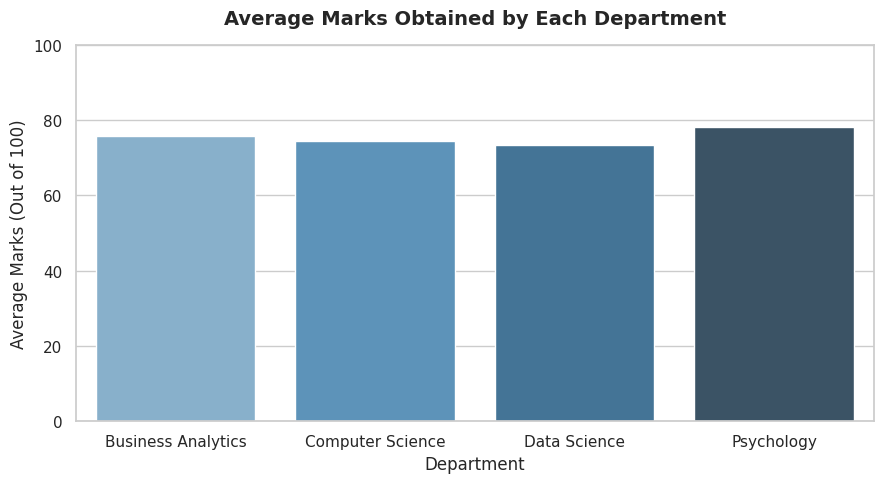

In [10]:
#set a clean background theme with gridlines and plot figure size
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))

#calculate department averages
df_dept_marks = df.groupby('Department')['Marks Obtained'].mean().reset_index()

#plot
sns.barplot(x='Department', y='Marks Obtained', data=df_dept_marks,hue='Department', legend=False, palette='Blues_d')
plt.title('Average Marks Obtained by Each Department', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Average Marks (Out of 100)', fontsize=12)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

**2. Student Distribution across Departments (Pie Chart)**

This chart illustrates the proportion of student enrollment in each department, ensuring we have a balanced representation of records.

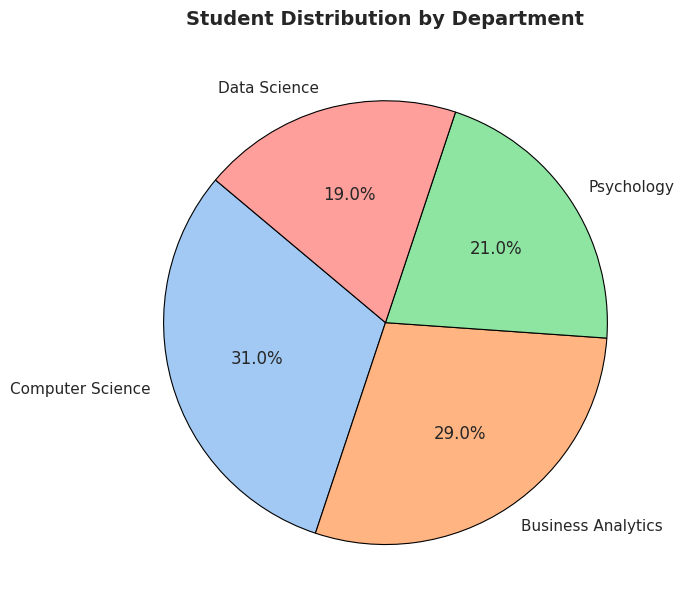

In [11]:
plt.figure(figsize=(7, 7))

#calculate counts
df_dept_counts = df['Department'].value_counts()

#plot
plt.pie(
    df_dept_counts,
    labels=df_dept_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('pastel')[0:4],
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
plt.title('Student Distribution by Department', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**3. Overall Marks Distribution (Histogram with KDE)**

The histogram displays the frequency distribution of marks. The Kernel Density Estimate (KDE) line helps us understand the overall spread and detect any skewness in student performance.

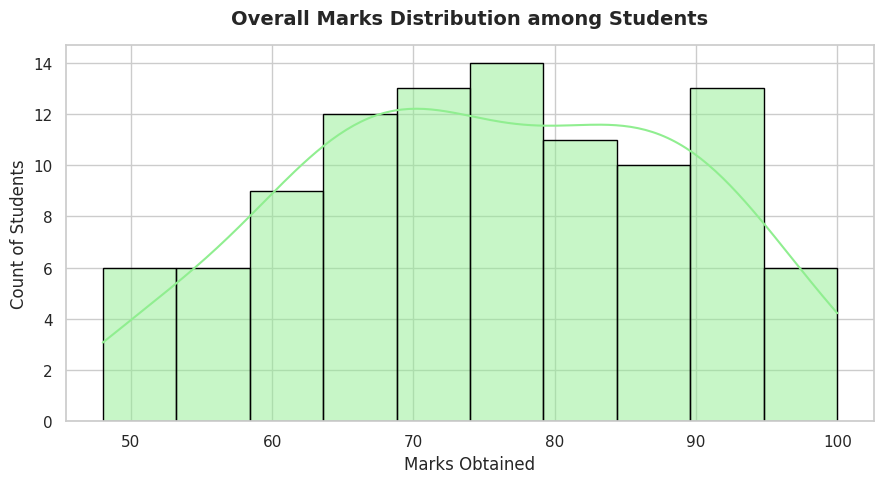

In [16]:
plt.figure(figsize=(9, 5))

#plot
sns.histplot(df['Marks Obtained'], bins=10, kde=True, color='lightgreen', edgecolor='black')
plt.title('Overall Marks Distribution among Students', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Marks Obtained', fontsize=12)
plt.ylabel('Count of Students', fontsize=12)
plt.tight_layout()
plt.show()

**4. Attendance Percentage vs Marks Trend (Line Chart)**

 By applying a rolling average to smooth individual noise, this line chart visually demonstrates the direct performance trend: higher attendance directly correlates with higher marks.

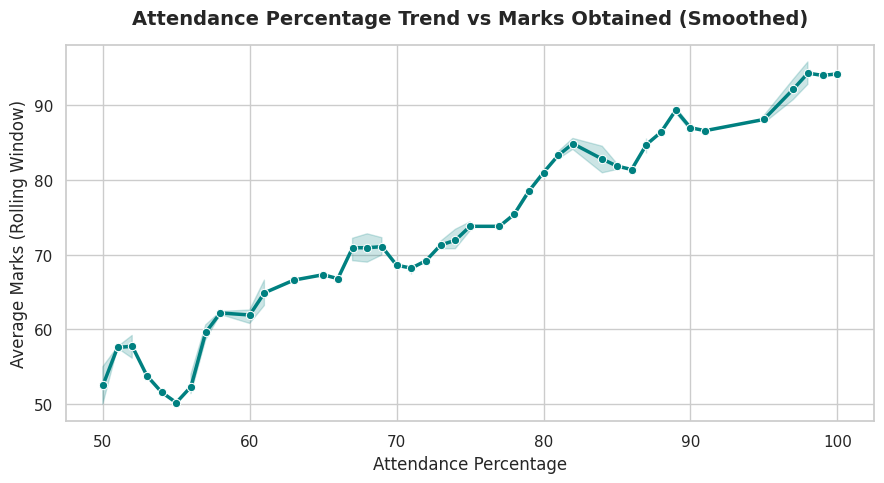

In [17]:
plt.figure(figsize=(9, 5))

#sort and calculate rolling mean
df_sorted = df.sort_values(by='Attendance Percentage')
df_sorted['Smoothed Marks'] = df_sorted['Marks Obtained'].rolling(window=5, min_periods=1).mean()

#plot
sns.lineplot(x='Attendance Percentage', y='Smoothed Marks', data=df_sorted, color='teal', linewidth=2.5, marker='o')
plt.title('Attendance Percentage Trend vs Marks Obtained (Smoothed)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Attendance Percentage', fontsize=12)
plt.ylabel('Average Marks (Rolling Window)', fontsize=12)
plt.tight_layout()
plt.show()